In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import geopandas
import folium
import plotly
import pydeck
import contextily
import shapely
import cartopy
import geemap
import ipyleaflet

c:\Users\abdalrahman\AppData\Local\Programs\Python\Python39\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\abdalrahman\AppData\Local\Programs\Python\Python39\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\abdalrahman\AppData\Local\Programs\Python\Python39\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using

In [3]:
import pandas as pd
df = pd.read_csv("clean_data.csv")


In [4]:
df.head(10)

,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56000,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73000,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91000,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89000,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,43.07198,1.867,15.93,17.3,48.7
5,2024-07-12,Los Angeles,132.0,27.46,75.30,65.83,49.39000,2.645,26.50,15.0,61.8
6,2024-08-27,San Antonio,94.0,21.58,51.07,52.83,44.50000,1.715,20.70,1.0,77.6
7,2023-02-02,New York,142.0,32.01,68.79,80.02,49.34000,2.138,13.24,27.9,59.3
8,2023-04-06,Houston,176.0,35.64,70.72,127.53,43.07198,2.538,17.39,43.3,23.9
9,2023-08-27,Dallas,80.0,21.36,48.06,65.93,36.57000,2.327,21.43,-1.7,77.9


In [5]:
m = folium.Map(
    location=[20, 0],
    zoom_start=2
)
m

In [6]:
df["City"].unique()

array(['Los Angeles', 'Jacksonville', 'Houston', 'Chicago', 'Austin',
       'San Antonio', 'New York', 'Dallas', 'San Diego', 'Phoenix',
       'Fort Worth', 'Philadelphia', 'San Jose', 'Charlotte', 'Columbus'],
      dtype=object)

In [7]:
import folium

# إحداثيات المدن
city_coordinates = {
    "Los Angeles": [34.0522, -118.2437],
    "Jacksonville": [30.3322, -81.6557],
    "Houston": [29.7604, -95.3698],
    "Chicago": [41.8781, -87.6298],
    "Austin": [30.2672, -97.7431],
    "San Antonio": [29.4241, -98.4936],
    "New York": [40.7128, -74.0060],
    "Dallas": [32.7767, -96.7970],
    "San Diego": [32.7157, -117.1611],
    "Phoenix": [33.4484, -112.0740],
    "Fort Worth": [32.7555, -97.3308],
    "Philadelphia": [39.9526, -75.1652],
    "San Jose": [37.3382, -121.8863],
    "Charlotte": [35.2271, -80.8431],
    "Columbus": [39.9612, -82.9988]
}
# إنشاء الخريطة
m = folium.Map(
    location=[39, -98],
    zoom_start=4
)
# إضافة كل المدن الموجودة في الداتا
for city in df["City"].unique():

    if city in city_coordinates:

        city_data = df[df["City"] == city].iloc[0]

        folium.Marker(
            location=city_coordinates[city],
            popup=f"""
            <b>City:</b> {city}<br>
            <b>Date:</b> {city_data["Date"]}<br>
            <b>AQI:</b> {city_data["AQI"]}<br>
            <b>PM2.5:</b> {city_data["PM2.5"]}<br>
            <b>PM10:</b> {city_data["PM10"]}<br>
            <b>Ozone:</b> {city_data["Ozone"]}<br>
            <b>NO2:</b> {city_data["NO2"]}<br>
            <b>CO:</b> {city_data["CO"]}<br>
            <b>SO2:</b> {city_data["SO2"]}<br>
            <b>Temperature:</b> {city_data["Temperature"]}<br>
            <b>Humidity:</b> {city_data["Humidity"]}
            """,
            tooltip=city
        ).add_to(m)

m

In [8]:
import folium

city_coordinates = {
    "Los Angeles": [34.0522, -118.2437],
    "Jacksonville": [30.3322, -81.6557],
    "Houston": [29.7604, -95.3698],
    "Chicago": [41.8781, -87.6298],
    "Austin": [30.2672, -97.7431],
    "San Antonio": [29.4241, -98.4936],
    "New York": [40.7128, -74.0060],
    "Dallas": [32.7767, -96.7970],
    "San Diego": [32.7157, -117.1613],
    "Phoenix": [33.4484, -112.0740],
    "Fort Worth": [32.7555, -97.3308],
    "Philadelphia": [39.9526, -75.1652],
    "San Jose": [37.3382, -121.8863],
    "Charlotte": [35.2271, -80.8431],
    "Columbus": [39.9612, -82.9988]
}

m = folium.Map(
    location=[39, -98],
    zoom_start=4
)

for city in df["City"].dropna().unique():

    if city not in city_coordinates:
        continue

    city_df = df[df["City"] == city]

    popup_text = f"<h3>{city}</h3>"
    popup_text += f"<b>Number of records:</b> {len(city_df)}<br><br>"

    for _, row in city_df.iterrows():

        popup_text += f"""
        <hr>
        <b>Date:</b> {row['Date']}<br>
        <b>AQI:</b> {row['AQI']}<br>
        <b>PM2.5:</b> {row['PM2.5']}<br>
        <b>PM10:</b> {row['PM10']}<br>
        <b>Ozone:</b> {row['Ozone']}<br>
        <b>NO2:</b> {row['NO2']}<br>
        <b>CO:</b> {row['CO']}<br>
        <b>SO2:</b> {row['SO2']}<br>
        <b>Temperature:</b> {row['Temperature']}<br>
        <b>Humidity:</b> {row['Humidity']}<br>
        """

    folium.Marker(
        location=city_coordinates[city],
        tooltip=city,
        popup=folium.Popup(
            popup_text,
            max_width=500
        )
    ).add_to(m)

m

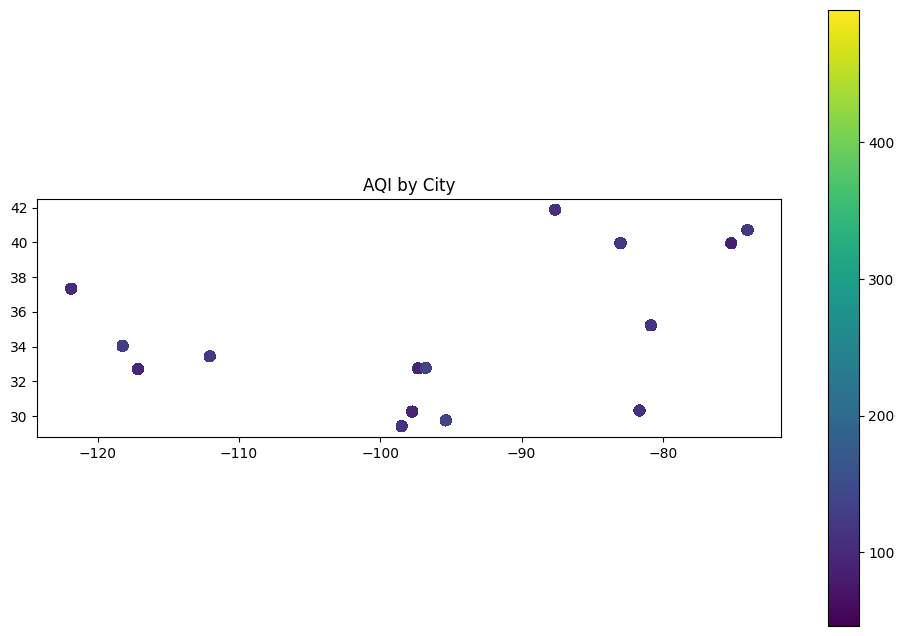

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

city_coordinates = {
    "Los Angeles": [34.0522, -118.2437],
    "Jacksonville": [30.3322, -81.6557],
    "Houston": [29.7604, -95.3698],
    "Chicago": [41.8781, -87.6298],
    "Austin": [30.2672, -97.7431],
    "San Antonio": [29.4241, -98.4936],
    "New York": [40.7128, -74.0060],
    "Dallas": [32.7767, -96.7970],
    "San Diego": [32.7157, -117.1613],
    "Phoenix": [33.4484, -112.0740],
    "Fort Worth": [32.7555, -97.3308],
    "Philadelphia": [39.9526, -75.1652],
    "San Jose": [37.3382, -121.8863],
    "Charlotte": [35.2271, -80.8431],
    "Columbus": [39.9612, -82.9988]
}

geo_df = df.copy()

geo_df["Latitude"] = geo_df["City"].map(
    {city: coord[0] for city, coord in city_coordinates.items()}
)

geo_df["Longitude"] = geo_df["City"].map(
    {city: coord[1] for city, coord in city_coordinates.items()}
)

gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(
        geo_df["Longitude"],
        geo_df["Latitude"]
    ),
    crs="EPSG:4326"
)

gdf.plot(
    column="AQI",
    legend=True,
    figsize=(12, 8),
    markersize=50
)

plt.title("AQI by City")
plt.show()

In [10]:
import pydeck as pdk

map_df = df.copy()


map_df["Latitude"] = map_df["City"].map(
    {city: coord[0] for city, coord in city_coordinates.items()}
)

map_df["Longitude"] = map_df["City"].map(
    {city: coord[1] for city, coord in city_coordinates.items()}
)

map_df = map_df.dropna(subset=["Latitude", "Longitude"])

layer = pdk.Layer(
    "ScatterplotLayer",
    data=map_df,
    get_position="[Longitude, Latitude]",
    get_radius=5000,
    get_fill_color="[AQI * 2, 100, 100]",
    pickable=True
)

view_state = pdk.ViewState(
    latitude=39,
    longitude=-98,
    zoom=3.5,
    pitch=45
)

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    tooltip={
        "text": "{City}\nAQI: {AQI}\nPM2.5: {PM2.5}"
    }
)

r

{
  "initialViewState": {
    "latitude": 39,
    "longitude": -98,
    "pitch": 45,
    "zoom": 3.5
  },
  "layers": [
    {
      "@@type": "ScatterplotLayer",
      "data": [
        {
          "AQI": 128.0,
          "CO": 2.781,
          "City": "Los Angeles",
          "Date": "2024-10-16",
          "Humidity": 82.2,
          "Latitude": 34.0522,
          "Longitude": -118.2437,
          "NO2": 57.56,
          "Ozone": 58.29,
          "PM10": 68.84,
          "PM2.5": 28.78,
          "SO2": 17.1,
          "Temperature": 3.4
        },
        {
          "AQI": 111.0,
          "CO": 1.81,
          "City": "Jacksonville",
          "Date": "2023-01-26",
          "Humidity": 36.0,
          "Latitude": 30.3322,
          "Longitude": -81.6557,
          "NO2": 35.73,
          "Ozone": 59.0,
          "PM10": 61.93,
          "PM2.5": 28.73,
          "SO2": 16.33,
          "Temperature": 17.0
        },
        {
          "AQI": 91.0,
          "CO": 2.566,
          "City": "Houston",
          "Date": "2023-10-09",
          "Humidity": 68.6,
          "Latitude": 29.7604,
          "Longitude": -95.3698,
          "NO2": 43.91,
          "Ozone": 66.2,
          "PM10": 47.1,
          "PM2.5": 20.04,
          "SO2": 15.27,
          "Temperature": 1.0
        },
        {
          "AQI": 108.0,
          "CO": 2.332,
          "City": "Chicago",
          "Date": "2023-08-17",
          "Humidity": 85.7,
          "Latitude": 41.8781,
          "Longitude": -87.6298,
          "NO2": 48.89,
          "Ozone": 62.85,
          "PM10": 47.9,
          "PM2.5": 23.39,
          "SO2": 18.49,
          "Temperature": 9.4
        },
        {
          "AQI": 106.0,
          "CO": 1.867,
          "City": "Austin",
          "Date": "2023-04-15",
          "Humidity": 48.7,
          "Latitude": 30.2672,
          "Longitude": -97.7431,
          "NO2": 43.07197996357012,
          "Ozone": 62.38,
          "PM10": 56.08,
          "PM2.5": 26.51,
          "SO2": 15.93,
          "Temperature": 17.3
        },
        {
          "AQI": 132.0,
          "CO": 2.645,
          "City": "Los Angeles",
          "Date": "2024-07-12",
          "Humidity": 61.8,
          "Latitude": 34.0522,
          "Longitude": -118.2437,
          "NO2": 49.39,
          "Ozone": 65.83,
          "PM10": 75.3,
          "PM2.5": 27.46,
          "SO2": 26.5,
          "Temperature": 15.0
        },
        {
          "AQI": 94.0,
          "CO": 1.715,
          "City": "San Antonio",
          "Date": "2024-08-27",
          "Humidity": 77.6,
          "Latitude": 29.4241,
          "Longitude": -98.4936,
          "NO2": 44.5,
          "Ozone": 52.83,
          "PM10": 51.07,
          "PM2.5": 21.58,
          "SO2": 20.7,
          "Temperature": 1.0
        },
        {
          "AQI": 142.0,
          "CO": 2.138,
          "City": "New York",
          "Date": "2023-02-02",
          "Humidity": 59.3,
          "Latitude": 40.7128,
          "Longitude": -74.006,
          "NO2": 49.34,
          "Ozone": 80.02,
          "PM10": 68.79,
          "PM2.5": 32.01,
          "SO2": 13.24,
          "Temperature": 27.9
        },
        {
          "AQI": 176.0,
          "CO": 2.538,
          "City": "Houston",
          "Date": "2023-04-06",
          "Humidity": 23.9,
          "Latitude": 29.7604,
          "Longitude": -95.3698,
          "NO2": 43.07197996357012,
          "Ozone": 127.53,
          "PM10": 70.72,
          "PM2.5": 35.64,
          "SO2": 17.39,
          "Temperature": 43.3
        },
        {
          "AQI": 80.0,
          "CO": 2.327,
          "City": "Dallas",
          "Date": "2023-08-27",
          "Humidity": 77.9,
          "Latitude": 32.7767,
          "Longitude": -96.797,
          "NO2": 36.57,
          "Ozone": 65.93,
          "PM10": 48.06,
          "PM2.5": 21.36,
          "SO2": 21.43,
          "Temperature": -1.7
        },
        {
          "AQI": 108.0,
    

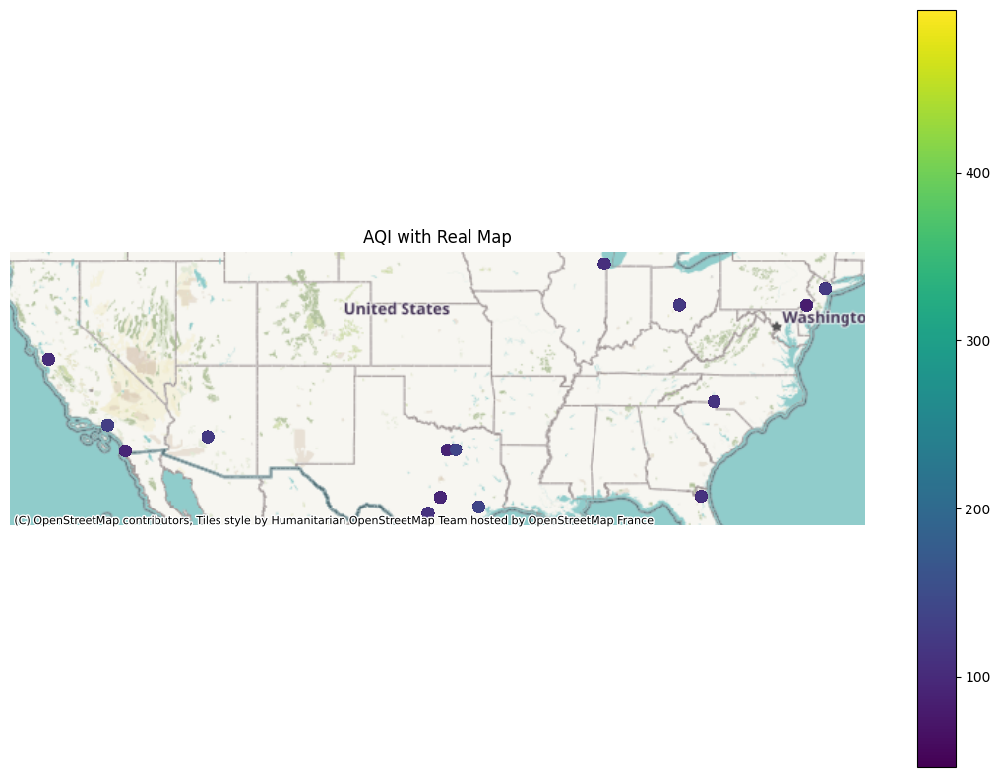

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

points = gdf.to_crs(epsg=3857)

ax = points.plot(
    figsize=(14, 10),
    column="AQI",
    legend=True,
    markersize=60
)

ctx.add_basemap(ax)

ax.set_axis_off()

plt.title("AQI with Real Map")
plt.show()

In [12]:
from shapely.geometry import Point

points = []

for city, coord in city_coordinates.items():

    point = Point(coord[1], coord[0])

    points.append({
        "City": city,
        "Geometry": point
    })

shapely_df = pd.DataFrame(points)

print(shapely_df)

            City                   Geometry
0    Los Angeles  POINT (-118.2437 34.0522)
1   Jacksonville   POINT (-81.6557 30.3322)
2        Houston   POINT (-95.3698 29.7604)
3        Chicago   POINT (-87.6298 41.8781)
4         Austin   POINT (-97.7431 30.2672)
5    San Antonio   POINT (-98.4936 29.4241)
6       New York    POINT (-74.006 40.7128)
7         Dallas    POINT (-96.797 32.7767)
8      San Diego  POINT (-117.1613 32.7157)
9        Phoenix   POINT (-112.074 33.4484)
10    Fort Worth   POINT (-97.3308 32.7555)
11  Philadelphia   POINT (-75.1652 39.9526)
12      San Jose  POINT (-121.8863 37.3382)
13     Charlotte   POINT (-80.8431 35.2271)
14      Columbus   POINT (-82.9988 39.9612)


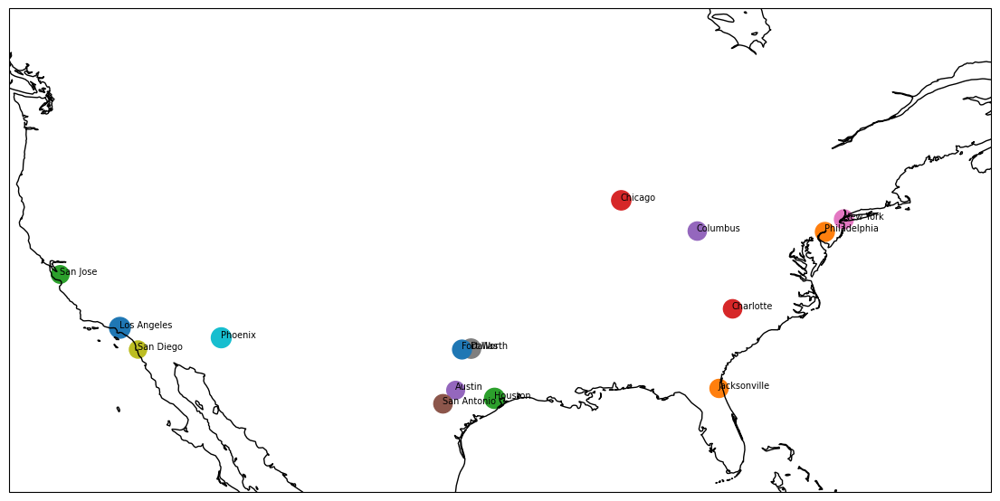

In [13]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.coastlines()

ax.set_extent(
    [-125, -65, 24, 50]
)

for city, coord in city_coordinates.items():

    city_df = df[df["City"] == city]

    avg_aqi = city_df["AQI"].mean()

    ax.scatter(
        coord[1],
        coord[0],
        s=avg_aqi * 2,
        transform=ccrs.PlateCarree()
    )

    ax.text(
        coord[1],
        coord[0],
        city,
        transform=ccrs.PlateCarree(),
        fontsize=7
    )
plt.show()